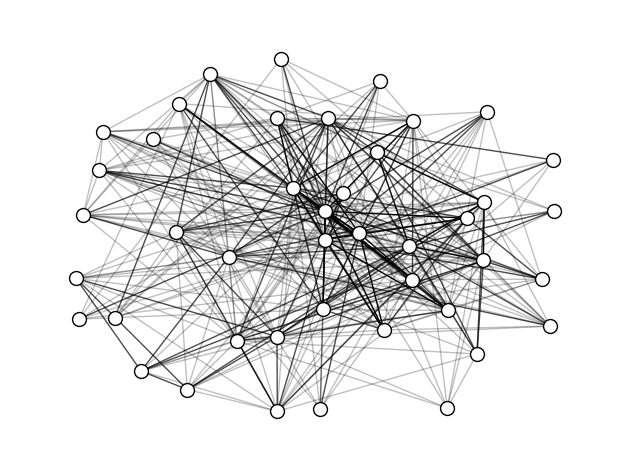

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

g = nx.read_weighted_edgelist("./ignore-files/out.moreno_beach_beach", delimiter=" ",comments='%',nodetype=int)

elarge = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] > 10]
emedium = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] > 2 and d['weight'] <= 10]
esmall = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] <= 2]
pos = nx.spring_layout(g, seed=7, k=3, gravity=2)  # positions for all nodes - seed for reproducibility
# nodes
nx.draw_networkx_nodes(g, pos, node_size=100, node_color='white', edgecolors='black')

# edges
nx.draw_networkx_edges(g, pos, edgelist=elarge, width=1)
nx.draw_networkx_edges(g, pos, edgelist=emedium, width=1, alpha=0.70)
nx.draw_networkx_edges(
    g, pos, edgelist=esmall, width=1, alpha=0.25
)

# node labels
# nx.draw_networkx_labels(g, pos, font_family="sans-serif")
# edge weight labels
# edge_labels = nx.get_edge_attributes(g, "weight")
# nx.draw_networkx_edge_labels(g, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12554/3207981322.py:4: SyntaxWarning: invalid escape sequence '\s'
  events = pd.read_csv('./output/events-SIS-I=   0.05000-R=   1.00000-S=42072.dat', sep='\s+', names=['t', 'node_id', 'action'])
595it [00:45, 12.96it/s]
/tmp/ipykernel_12554/3207981322.py:4: SyntaxWarning: invalid escape sequence '\s'
  events = pd.read_csv('./output/events-SIS-I=   0.05000-R=   1.00000-S=42072.dat', sep='\s+', names=['t', 'node_id', 'action'])


KeyboardInterrupt: 

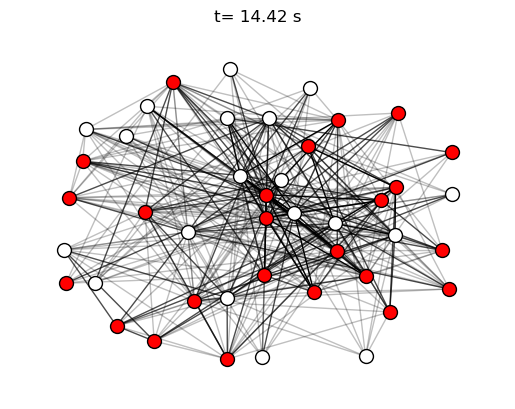

In [33]:
import pandas as pd
from tqdm import tqdm

events = pd.read_csv('./output/events-SIS-I=   0.05000-R=   1.00000-S=42072.dat', sep='\s+', names=['t', 'node_id', 'action'])

g = nx.read_weighted_edgelist("./ignore-files/out.moreno_beach_beach", delimiter=" ",comments='%',nodetype=int)
infected = set()
susceptible = set(g.nodes())
elarge = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] > 10]
emedium = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] > 2 and d['weight'] <= 10]
esmall = [(u, v) for (u, v, d) in g.edges(data=True) if d["weight"] <= 2]

for index, event in tqdm(events.iterrows()):
    if (event['action'] == 'I'):
        susceptible.remove(event['node_id'])
        infected.add(event['node_id'])
    else: # event == 'R'
        infected.remove(event['node_id'])
        susceptible.add(event['node_id'])

    # nodes
    nx.draw_networkx_nodes(g, pos, nodelist=susceptible, node_size=100, node_color='white', edgecolors='black')
    nx.draw_networkx_nodes(g, pos, nodelist=infected, node_size=100, node_color='red', edgecolors='black')

    # edges
    nx.draw_networkx_edges(g, pos, edgelist=elarge, width=1)
    nx.draw_networkx_edges(g, pos, edgelist=emedium, width=1, alpha=0.70)
    nx.draw_networkx_edges(
        g, pos, edgelist=esmall, width=1, alpha=0.25
    )

    # node labels
    # nx.draw_networkx_labels(g, pos, font_family="sans-serif")
    # edge weight labels
    # edge_labels = nx.get_edge_attributes(g, "weight")
    # nx.draw_networkx_edge_labels(g, pos, edge_labels)
    t = event['t']
    ax = plt.gca()
    ax.margins(0.08)
    ax.set_title(f"t={t:6.2f} s")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f'./post-process/gif/wSIS-moreno-{index}.png')
    plt.close()

    